# Задача регрессии

В случае задач машинного обучения с учителем существует какое-то количество размеченных данных, данных, для которых определен корректный ответ и корректное предсказание. Мы пытаемся обучить нашу модель на этих данных и потом сделать предсказание на новых данных, которых мы еще не видели. Далее когда поступают новые данные, не размеченные, наша обученная модель пытается предсказать для них ответ.

В этом разделе мы посмотрим на одну из задач машинного обучения с учителем - это задача регрессии.

**Задача регрессии** (прогнозирования) – построение модели, способной предсказывать численную величину на основе набора признаков объекта.

**Регрессия. Постановка задачи.**

Есть обучающая выборка, в которой представлены объекты в виде из признакового описания (вектор признаков) и значения целевой переменной (непрерывная переменная).

Алгоритм регрессии дл каждого нового объекта (его признакового описания) прогнозирует значение целевой переменной.

**Ответ в задачах регресии является числовым из непрерывного диапазона, в отличии от задач классификации, где ответ дискретный.**

# Линейная регрессия

Самый простой способ посчитать регрессиию, предположить, что есть некая линейная зависимость от признаков.

$$f_{w,b}(x) = wx + b$$

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Мы ещё отдельно разберём как считать ошибки, но, упрощённо говоря, достаточно считать квадрат разности между настоящими и посчитанными значениями.

$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})^2$$

Подбирать параметры поможет градиентный спуск.

$$w \leftarrow w - \alpha \frac{\partial J}{\partial w}$$

$$b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

Для него нужно посчитать производные ошибки по параметрам.

$$
\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(X^{(i)}) - y^{(i)})
$$

$$
\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(X^{(i)}) - y^{(i)})X^{(i)}
$$

In [4]:
class LinearRegression() :

    def __init__(self, learning_rate, iterations) :
        self.lr = learning_rate
        self.iter = iterations
        self.w = None
        self.b = None

        self.loss_h = []
        # не забудьте сохранить параметры во внутренние переменные

    def fit(self, X, Y) :
        # классический метод для тренировки
        self.w = np.zeros(X.shape[1])
        self.b = 0

        for i in range(self.iter) :
            e = self.update_weights(X, Y)
            self.loss_h.append(e)
            # здесь код изменения весов, правильнее его вынести в отдельный метод      

    def update_weights( self, X, Y ) :
        preds = X @ self.w + self.b
        e = preds - Y
        self.w = self.w - self.lr * (e.T @ X) / X.shape[0]
        self.b = self.b - self.lr * np.sum(e) / X.shape[0]
        
            # здесь код для изменения весов
        return e.T @ e

    def predict( self, X ) :
        
            # а тут предсказание значений
        return X @ self.w + self.b

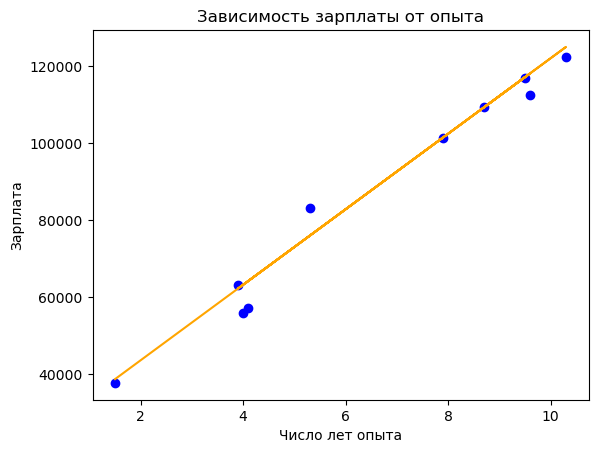

In [12]:
df = pd.read_csv( "salary_data.csv" )

X = df.iloc[:,:-1].values
Y = df.iloc[:,1].values

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 1/3, random_state = 0 )

model = LinearRegression(iterations = 1000, learning_rate = 0.01)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)


plt.scatter(X_test, Y_test, color = 'blue')
plt.plot(X_test, Y_pred, color = 'orange')
plt.title('Зависимость зарплаты от опыта')
plt.xlabel('Число лет опыта')
plt.ylabel('Зарплата')

plt.show()